# Previsão de preços de carros

## passo 0 — importação de bibliotecas

In [1]:
# importação de bibliotecas para manipulação, visualização e modelagem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats

# pré-processamento
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# modelagem
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# métricas
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# configurações globais
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# semente para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('bibliotecas importadas com sucesso.')
import joblib

bibliotecas importadas com sucesso.


## passo 1 — carregamento e inspeção do dataset

### 1.1 carregamento e dimensões

In [2]:
# carregamento do dataset
df = pd.read_csv('../data/dataset.csv')

# dimensões
print(f'dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas')

dimensões do dataset: 205 linhas × 26 colunas


### 1.2 visualização das primeiras e últimas linhas

In [3]:
# primeiras 10 linhas
df.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


In [4]:
# últimas 5 linhas
df.tail(5)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3062,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0


### 1.3 tipos de dados e informações gerais

In [5]:
# tipos de dados de cada coluna
df.dtypes

car_ID                int64
symboling             int64
CarName                 str
fueltype                str
aspiration              str
doornumber              str
carbody                 str
drivewheel              str
enginelocation          str
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype              str
cylindernumber          str
enginesize            int64
fuelsystem              str
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

In [6]:
# informações gerais do dataset (tipos, memória, nulos)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

### 1.4 estatísticas descritivas

In [7]:
# estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


In [8]:
# estatísticas descritivas das variáveis categóricas
df.describe(include=['O']).T

,count,unique,top,freq
CarName,205,147,peugeot 504,6
fueltype,205,2,gas,185
aspiration,205,2,std,168
doornumber,205,2,four,115
carbody,205,5,sedan,96
drivewheel,205,3,fwd,120
enginelocation,205,2,front,202
enginetype,205,7,ohc,148
cylindernumber,205,7,four,159
fuelsystem,205,8,mpfi,94


### 1.5 análise de valores faltantes

In [9]:
# contagem e percentual de valores nulos por coluna
faltantes = df.isnull().sum()
percentual = (df.isnull().mean() * 100).round(1)

print('análise de valores faltantes:')
for col in df.columns:
    print(f'  {col:25s} {faltantes[col]:3d} ({percentual[col]:.1f}%)')

print(f'\ntotal de valores nulos: {faltantes.sum()}')

análise de valores faltantes:
  car_ID                      0 (0.0%)
  symboling                   0 (0.0%)
  CarName                     0 (0.0%)
  fueltype                    0 (0.0%)
  aspiration                  0 (0.0%)
  doornumber                  0 (0.0%)
  carbody                     0 (0.0%)
  drivewheel                  0 (0.0%)
  enginelocation              0 (0.0%)
  wheelbase                   0 (0.0%)
  carlength                   0 (0.0%)
  carwidth                    0 (0.0%)
  carheight                   0 (0.0%)
  curbweight                  0 (0.0%)
  enginetype                  0 (0.0%)
  cylindernumber              0 (0.0%)
  enginesize                  0 (0.0%)
  fuelsystem                  0 (0.0%)
  boreratio                   0 (0.0%)
  stroke                      0 (0.0%)
  compressionratio            0 (0.0%)
  horsepower                  0 (0.0%)
  peakrpm                     0 (0.0%)
  citympg                     0 (0.0%)
  highwaympg                  0 (0

### 1.6 verificação de duplicatas e valores únicos

In [10]:
# verificação de linhas duplicadas
duplicadas = df.duplicated().sum()
print(f'linhas duplicadas: {duplicadas}')

linhas duplicadas: 0


In [11]:
# contagem de valores únicos por coluna
df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

---

## etapa 1 — análise exploratória (eda)

exploração visual e estatística das variáveis do dataset, com foco na variável alvo `price`.

### 1.1 distribuição da variável alvo (`price`)

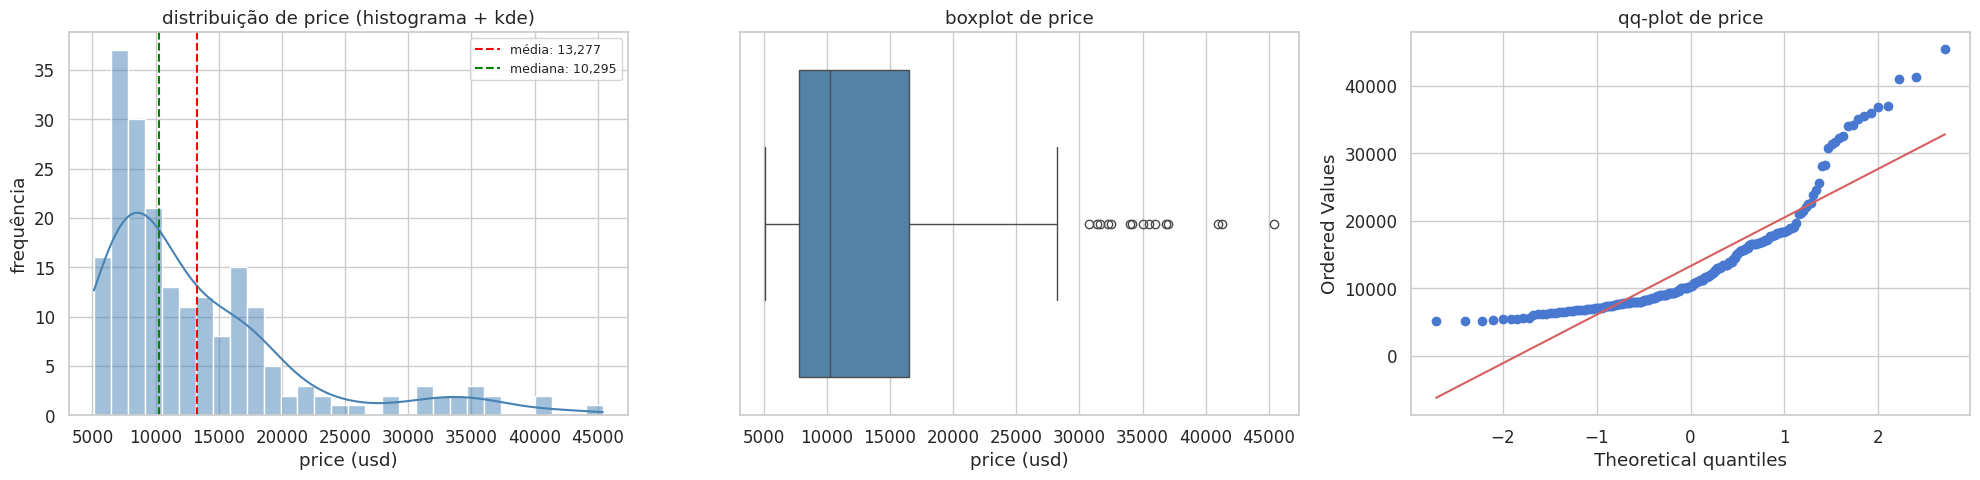

In [12]:
# histograma com kde, boxplot e qq-plot de price
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# histograma + kde
sns.histplot(df['price'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('distribuição de price (histograma + kde)')
axes[0].set_xlabel('price (usd)')
axes[0].set_ylabel('frequência')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'média: {df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f'mediana: {df["price"].median():,.0f}')
axes[0].legend(fontsize=9)

# boxplot
sns.boxplot(x=df['price'], color='steelblue', ax=axes[1])
axes[1].set_title('boxplot de price')
axes[1].set_xlabel('price (usd)')

# qq-plot para verificar normalidade
stats.probplot(df['price'], dist='norm', plot=axes[2])
axes[2].set_title('qq-plot de price')

plt.tight_layout()
plt.show()

In [13]:
# estatísticas descritivas detalhadas da variável alvo
print('estatísticas de price:')
print(f'  média:       {df["price"].mean():>12,.2f}')
print(f'  mediana:     {df["price"].median():>12,.2f}')
print(f'  desvio:      {df["price"].std():>12,.2f}')
print(f'  mínimo:      {df["price"].min():>12,.2f}')
print(f'  máximo:      {df["price"].max():>12,.2f}')
print(f'  q1 (25%):    {df["price"].quantile(0.25):>12,.2f}')
print(f'  q3 (75%):    {df["price"].quantile(0.75):>12,.2f}')
print(f'  assimetria:  {df["price"].skew():>12.4f}')
print(f'  curtose:     {df["price"].kurtosis():>12.4f}')

# teste de normalidade shapiro-wilk na variável alvo
stat_sw, p_sw = stats.shapiro(df['price'])
print(f'\n  shapiro-wilk: W={stat_sw:.4f}, p-valor={p_sw:.6f}')
print(f'  conclusão: distribuição {"normal" if p_sw > 0.05 else "não-normal"} (α=0.05)')

estatísticas de price:
  média:          13,276.71
  mediana:        10,295.00
  desvio:          7,988.85
  mínimo:          5,118.00
  máximo:         45,400.00
  q1 (25%):        7,788.00
  q3 (75%):       16,503.00
  assimetria:        1.7777
  curtose:           3.0516

  shapiro-wilk: W=0.8007, p-valor=0.000000
  conclusão: distribuição não-normal (α=0.05)


### 1.2 scatter plots

> **nota:** o dataset não possui coluna `year`. ele é derivado do 1985 automobile dataset, portanto todos os veículos são do mesmo período. a coluna `symboling` (índice de risco de seguro, de -2 a 3) é utilizada no scatter plot substituto. a variável `car_age` será criada como constante na etapa de pré-processamento.

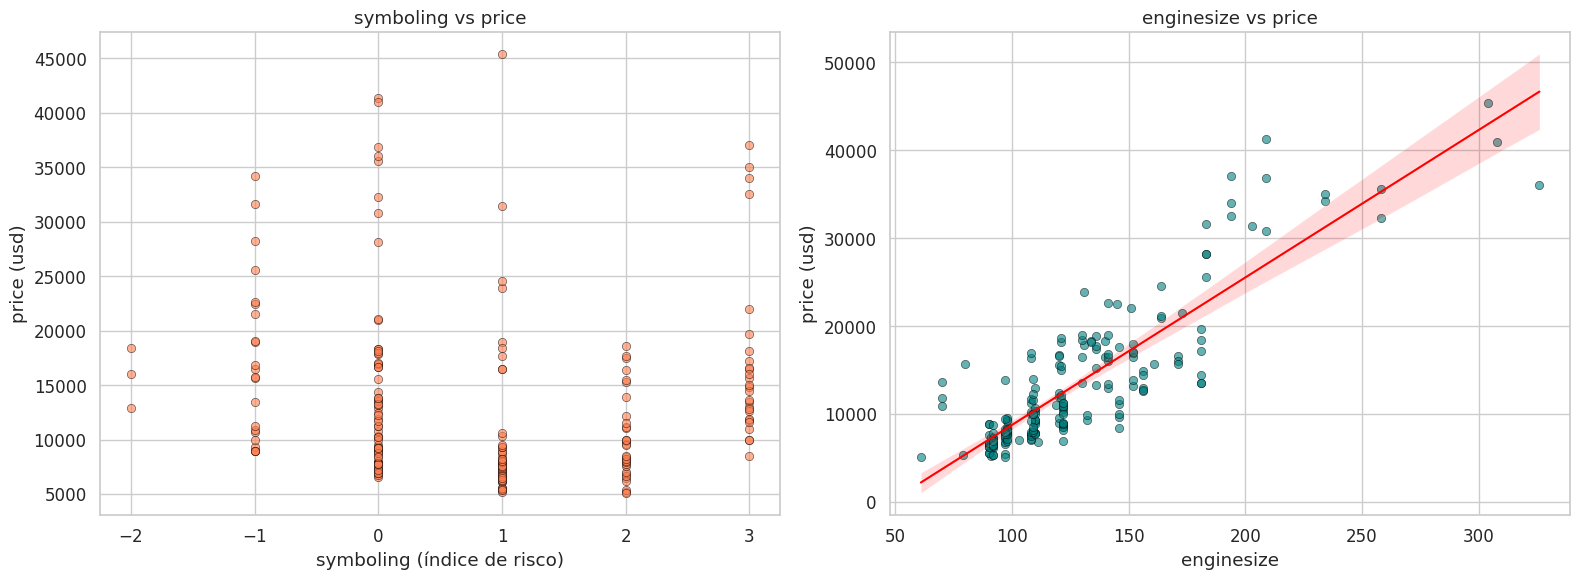

In [14]:
# scatter plots: symboling vs price e enginesize vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# symboling vs price (substituto de year vs price)
sns.scatterplot(data=df, x='symboling', y='price', alpha=0.6,
                color='coral', edgecolor='black', linewidth=0.5, ax=axes[0])
axes[0].set_title('symboling vs price')
axes[0].set_xlabel('symboling (índice de risco)')
axes[0].set_ylabel('price (usd)')

# enginesize vs price
sns.regplot(data=df, x='enginesize', y='price', scatter_kws={'alpha': 0.6, 'edgecolor': 'black', 'linewidths': 0.5},
            line_kws={'color': 'red', 'linewidth': 1.5}, color='teal', ax=axes[1])
axes[1].set_title('enginesize vs price')
axes[1].set_xlabel('enginesize')
axes[1].set_ylabel('price (usd)')

plt.tight_layout()
plt.show()

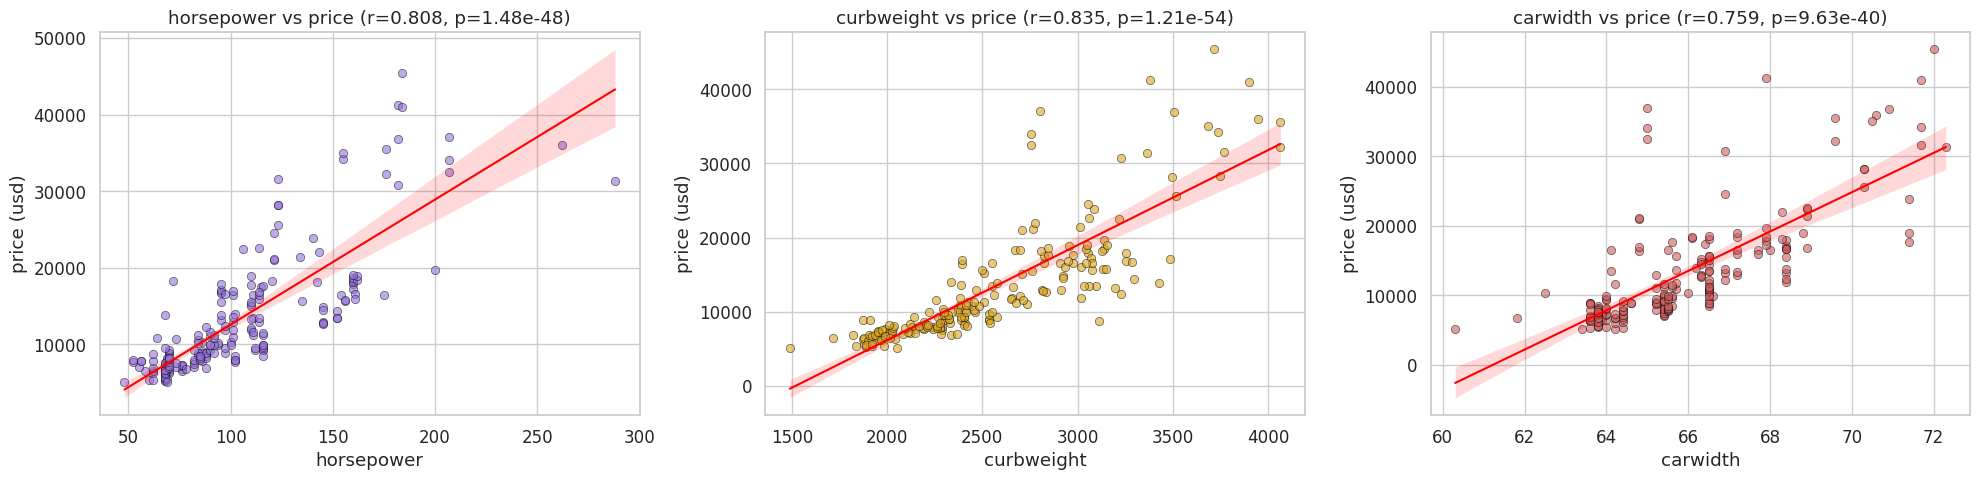

In [15]:
# scatter plots complementares: preditores fortes (horsepower, curbweight, carwidth)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, cor in zip(axes,
    ['horsepower', 'curbweight', 'carwidth'],
    ['mediumpurple', 'goldenrod', 'indianred']):
    sns.regplot(data=df, x=col, y='price',
                scatter_kws={'alpha': 0.6, 'edgecolor': 'black', 'linewidths': 0.5},
                line_kws={'color': 'red', 'linewidth': 1.5},
                color=cor, ax=ax)
    # correlação de pearson
    r, p = stats.pearsonr(df[col], df['price'])
    ax.set_title(f'{col} vs price (r={r:.3f}, p={p:.2e})')
    ax.set_xlabel(col)
    ax.set_ylabel('price (usd)')

plt.tight_layout()
plt.show()

### 1.3 boxplots — price por variáveis categóricas

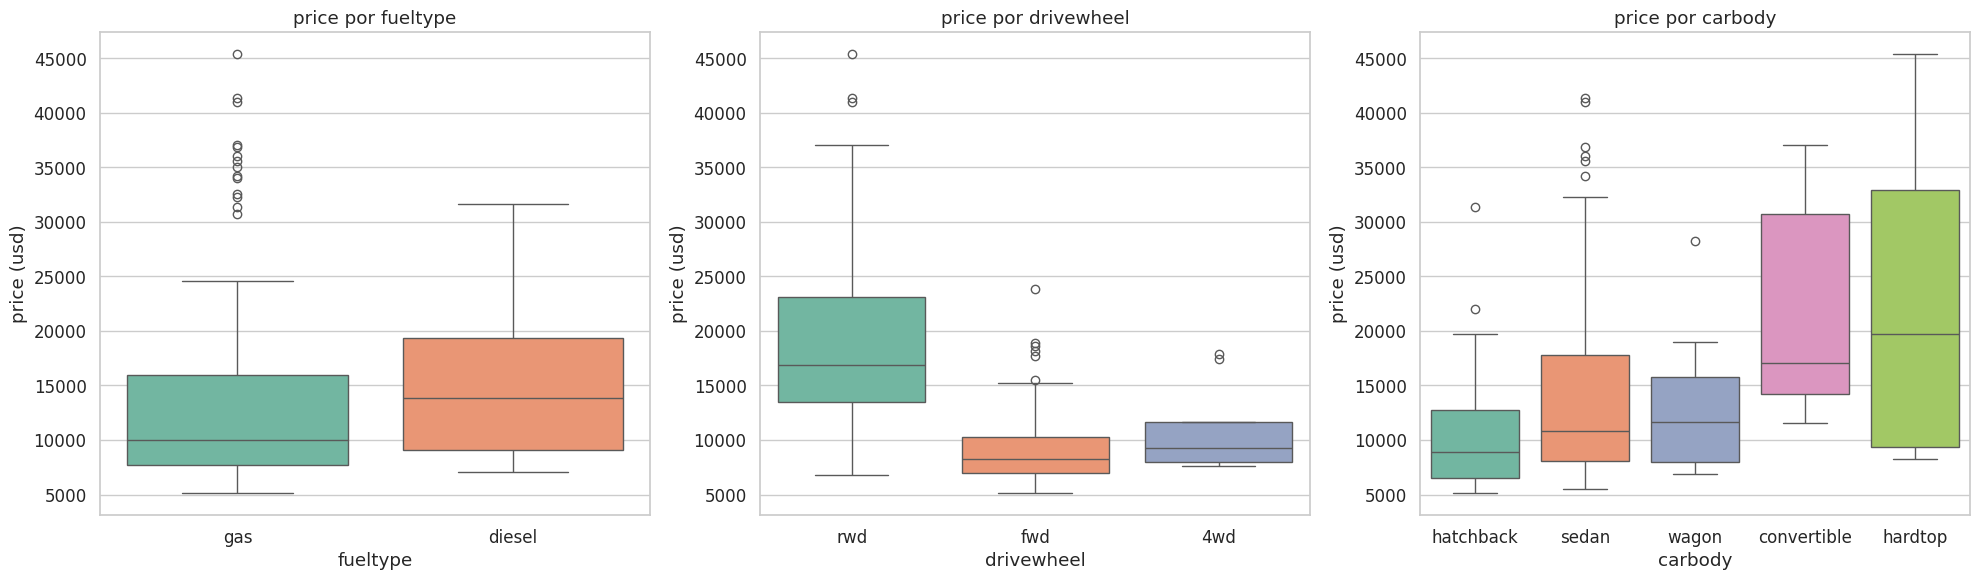

In [16]:
# boxplots de price por fueltype, drivewheel e carbody
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='fueltype', y='price', palette='Set2', ax=axes[0])
axes[0].set_title('price por fueltype')
axes[0].set_xlabel('fueltype')
axes[0].set_ylabel('price (usd)')

sns.boxplot(data=df, x='drivewheel', y='price', palette='Set2', ax=axes[1])
axes[1].set_title('price por drivewheel')
axes[1].set_xlabel('drivewheel')
axes[1].set_ylabel('price (usd)')

sns.boxplot(data=df, x='carbody', y='price', palette='Set2', ax=axes[2],
            order=df.groupby('carbody')['price'].median().sort_values().index)
axes[2].set_title('price por carbody')
axes[2].set_xlabel('carbody')
axes[2].set_ylabel('price (usd)')

plt.tight_layout()
plt.show()

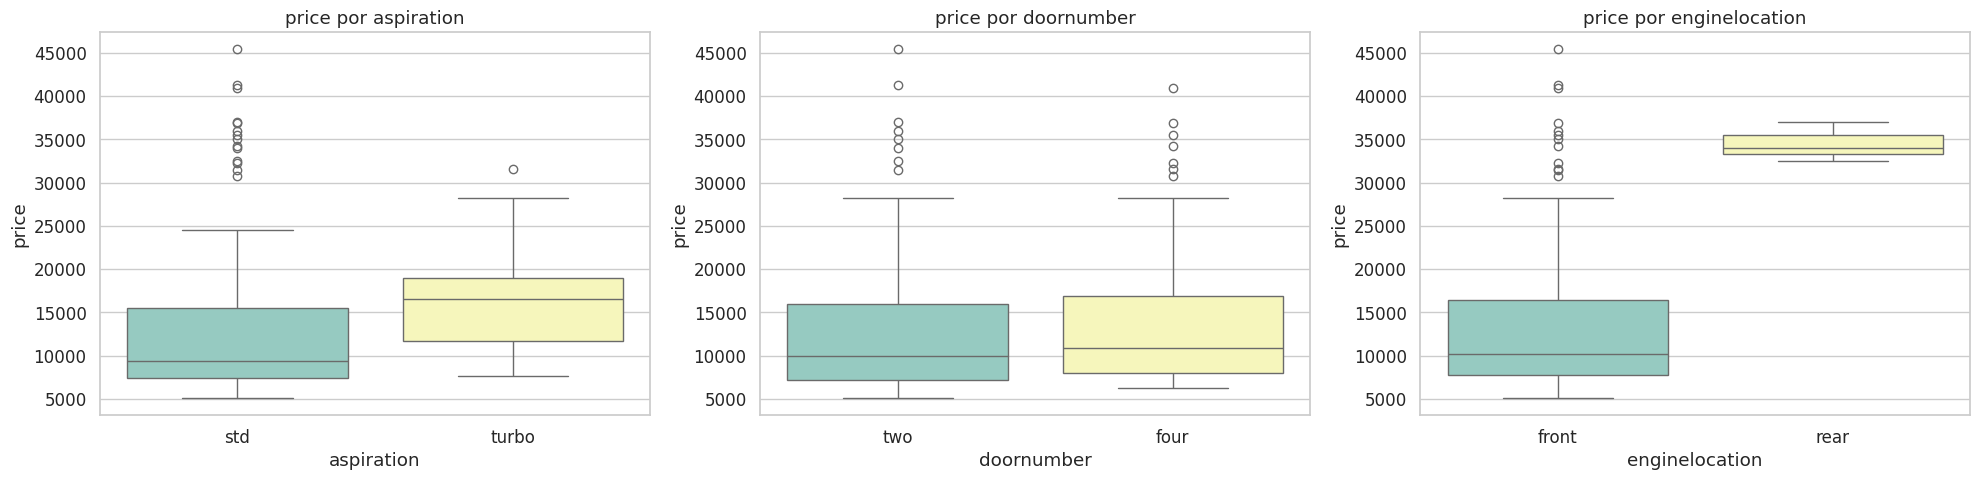

In [17]:
# boxplots complementares: price por aspiration, doornumber e enginelocation
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=df, x='aspiration', y='price', palette='Set3', ax=axes[0])
axes[0].set_title('price por aspiration')

sns.boxplot(data=df, x='doornumber', y='price', palette='Set3', ax=axes[1])
axes[1].set_title('price por doornumber')

sns.boxplot(data=df, x='enginelocation', y='price', palette='Set3', ax=axes[2])
axes[2].set_title('price por enginelocation')

plt.tight_layout()
plt.show()

### 1.4 preço médio por marca

In [18]:
# extração provisória da marca a partir de carname
df['brand_temp'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# correção de nomes inconsistentes identificados no dataset
brand_corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'alfa-romero': 'alfa-romeo'
}
df['brand_temp'] = df['brand_temp'].replace(brand_corrections)

# verificação das marcas únicas após correção
print(f'marcas únicas após correção: {df["brand_temp"].nunique()}')
print(sorted(df['brand_temp'].unique()))

marcas únicas após correção: 22
['alfa-romeo', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


In [19]:
# preço médio, mediana, desvio e contagem por marca
preco_marca = (
    df.groupby('brand_temp')['price']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'média', 'median': 'mediana', 'std': 'desvio', 'count': 'qtd'})
    .round(2)
)
print(preco_marca.to_string())

               média  mediana   desvio  qtd
brand_temp                                 
jaguar      34600.00  35550.0  2047.56    3
buick       33647.00  32892.0  6789.56    8
porsche     31400.50  32528.0  5654.09    5
bmw         26118.75  22835.0  9263.83    8
volvo       18063.18  18420.0  3314.65   11
audi        17859.17  17710.0  3151.58    7
mercury     16503.00  16503.0      NaN    1
alfa-romeo  15498.33  16500.0  1734.94    3
peugeot     15489.09  16630.0  2246.75   11
saab        15223.33  15275.0  2860.79    6
mazda       10652.88  10595.0  3975.68   17
nissan      10415.67   8124.0  4477.39   18
volkswagen  10077.50   9737.5  2178.55   12
toyota       9885.81   9103.0  3204.98   32
renault      9595.00   9595.0   424.26    2
mitsubishi   9239.77   8499.0  3043.00   13
isuzu        8916.50   8916.5  1740.36    4
subaru       8541.25   7894.0  1940.19   12
honda        8184.69   7295.0  2061.67   13
plymouth     7963.43   7609.0  2395.54    7
dodge        7875.44   7609.0  2

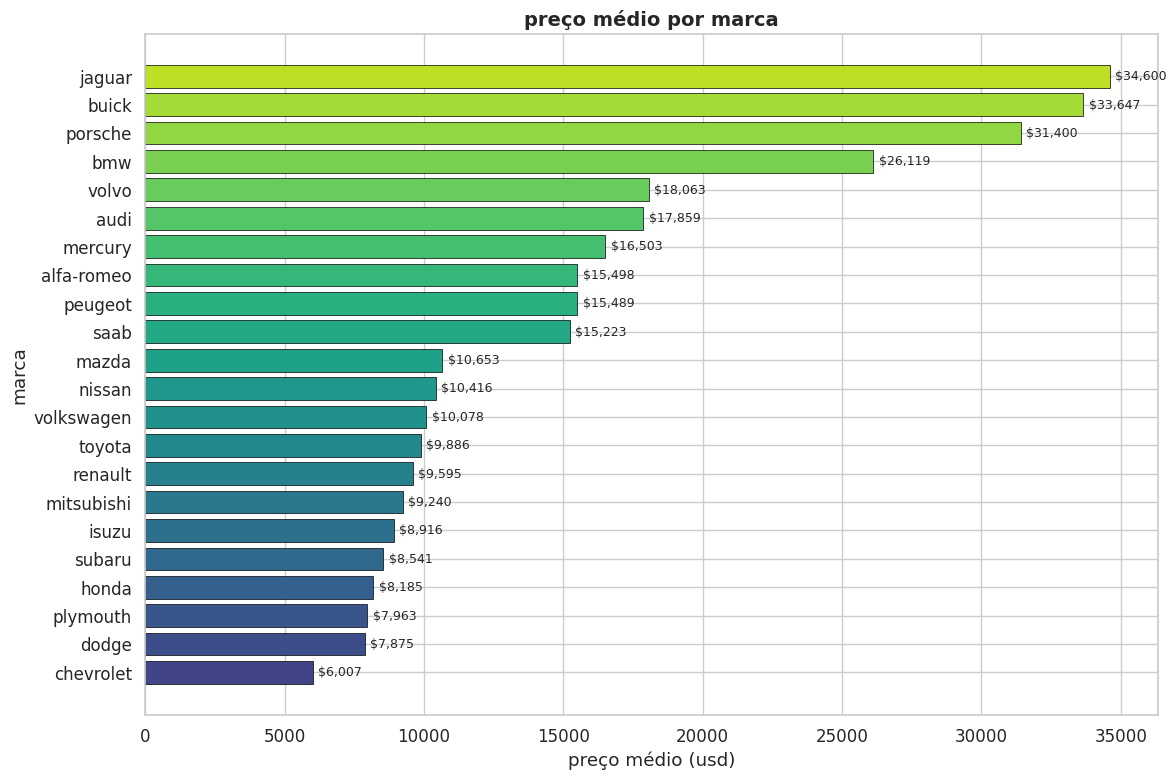

In [20]:
# gráfico de barras horizontal do preço médio por marca
fig, ax = plt.subplots(figsize=(12, 8))

preco_ordenado = preco_marca.sort_values('média', ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(preco_ordenado)))

bars = ax.barh(preco_ordenado.index, preco_ordenado['média'],
               color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, preco_ordenado['média']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_title('preço médio por marca', fontsize=14, fontweight='bold')
ax.set_xlabel('preço médio (usd)')
ax.set_ylabel('marca')

plt.tight_layout()
plt.show()

### 1.5 heatmap de correlação

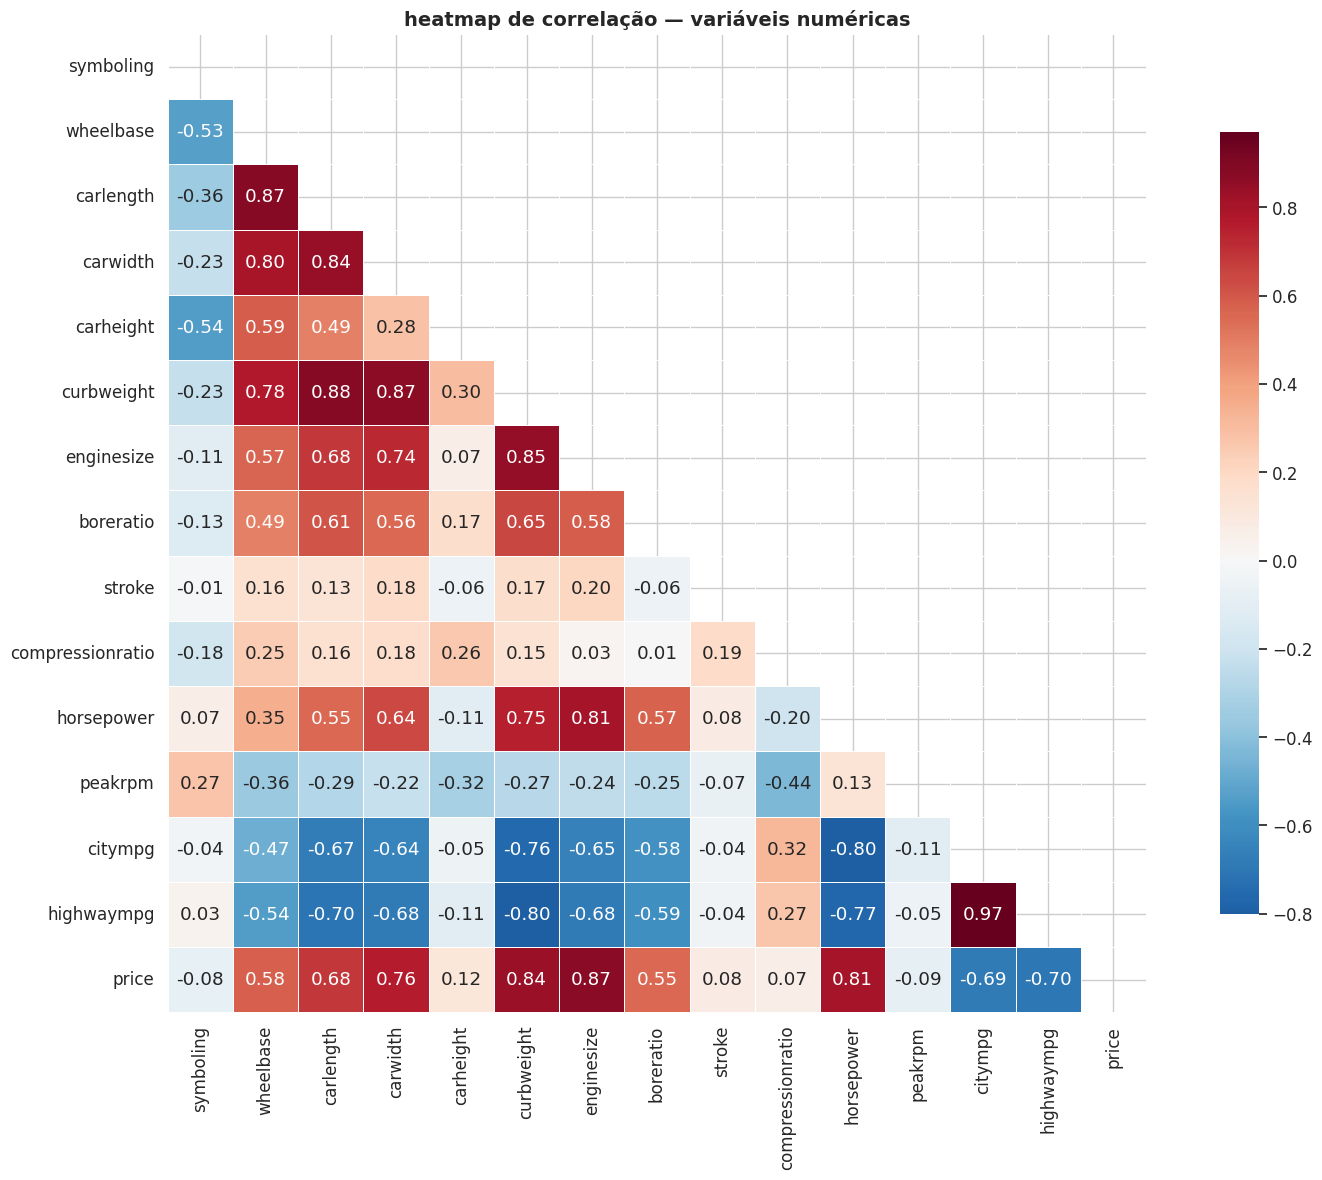

In [21]:
# seleção de variáveis numéricas (exceto car_id)
numericas_eda = df.select_dtypes(include=[np.number]).drop(columns=['car_ID'])

# matriz de correlação
corr_matrix = numericas_eda.corr()

# heatmap com máscara triangular
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    square=True, cbar_kws={'shrink': 0.8}, ax=ax
)

ax.set_title('heatmap de correlação — variáveis numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ranking de correlações com a variável alvo price
corr_price = (
    corr_matrix['price'].drop('price')
    .sort_values(key=abs, ascending=False)
)

print('correlação com price (ordenada por valor absoluto):')
print(f'{"variável":>25s}  {"correlação":>12s}  {"interpretação":>15s}')
print('-' * 58)
for col, val in corr_price.items():
    forca = 'forte' if abs(val) > 0.7 else 'moderada' if abs(val) > 0.4 else 'fraca'
    print(f'{col:>25s}  {val:>+12.4f}  {forca:>15s}')

correlação com price (ordenada por valor absoluto):
                 variável    correlação    interpretação
----------------------------------------------------------
               enginesize       +0.8741            forte
               curbweight       +0.8353            forte
               horsepower       +0.8081            forte
                 carwidth       +0.7593            forte
               highwaympg       -0.6976         moderada
                  citympg       -0.6858         moderada
                carlength       +0.6829         moderada
                wheelbase       +0.5778         moderada
                boreratio       +0.5532         moderada
                carheight       +0.1193            fraca
                  peakrpm       -0.0853            fraca
                symboling       -0.0800            fraca
                   stroke       +0.0794            fraca
         compressionratio       +0.0680            fraca


In [23]:
# remoção da coluna temporária
df.drop(columns=['brand_temp'], inplace=True)
print('coluna auxiliar brand_temp removida.')

coluna auxiliar brand_temp removida.


---

## etapa 2 — pré-processamento

preparação dos dados: tratamento de valores ausentes, engenharia de features, detecção de outliers, encoding e normalização.

### 2.1 tratamento de valores missing

In [24]:
# verificação detalhada de valores ausentes
faltantes = df.isnull().sum()
percentual = (df.isnull().mean() * 100).round(1)

print('análise de valores faltantes:')
for col in df.columns:
    print(f'  {col:25s} {faltantes[col]:3d} ({percentual[col]:.1f}%)')

print(f'\ntotal de nulos: {faltantes.sum()}')
print('\no dataset não possui valores ausentes; nenhuma imputação é necessária.')
print('em cenários reais, utilizaríamos simpleimputer (mediana para numéricas, moda para categóricas).')

análise de valores faltantes:
  car_ID                      0 (0.0%)
  symboling                   0 (0.0%)
  CarName                     0 (0.0%)
  fueltype                    0 (0.0%)
  aspiration                  0 (0.0%)
  doornumber                  0 (0.0%)
  carbody                     0 (0.0%)
  drivewheel                  0 (0.0%)
  enginelocation              0 (0.0%)
  wheelbase                   0 (0.0%)
  carlength                   0 (0.0%)
  carwidth                    0 (0.0%)
  carheight                   0 (0.0%)
  curbweight                  0 (0.0%)
  enginetype                  0 (0.0%)
  cylindernumber              0 (0.0%)
  enginesize                  0 (0.0%)
  fuelsystem                  0 (0.0%)
  boreratio                   0 (0.0%)
  stroke                      0 (0.0%)
  compressionratio            0 (0.0%)
  horsepower                  0 (0.0%)
  peakrpm                     0 (0.0%)
  citympg                     0 (0.0%)
  highwaympg                  0 (0

### 2.2 feature engineering

#### 2.2.1 extração e correção da marca

In [25]:
# extração da marca a partir da coluna carname
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# correção de nomes inconsistentes
brand_corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'alfa-romero': 'alfa-romeo'
}
df['brand'] = df['brand'].replace(brand_corrections)

print(f'marcas únicas após correção: {df["brand"].nunique()}')
print(sorted(df['brand'].unique()))

marcas únicas após correção: 22
['alfa-romeo', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


#### 2.2.2 criação da variável car_age

In [26]:
# criação da variável car_age
# o dataset é derivado do 1985 automobile dataset
# todos os veículos pertencem ao período de 1985
ANO_ATUAL = 2026
ANO_VEICULO = 1985

df['car_age'] = ANO_ATUAL - ANO_VEICULO

print(f'car_age: {df["car_age"].iloc[0]} anos (constante)')
print('justificativa: dataset sem coluna year; todos os veículos datam de ~1985.')
print('consequência: car_age não discrimina entre veículos; variância zero.')

car_age: 41 anos (constante)
justificativa: dataset sem coluna year; todos os veículos datam de ~1985.
consequência: car_age não discrimina entre veículos; variância zero.


#### 2.2.3 extração do modelo do carro

In [27]:
# extração do modelo do carro (parte após o nome da marca)
df['car_model'] = df['CarName'].apply(lambda x: ' '.join(x.split(' ')[1:]).lower().strip())

# verificação
print(f'modelos únicos: {df["car_model"].nunique()}')
print(df[['CarName', 'brand', 'car_model']].head(10).to_string())

modelos únicos: 142
                    CarName       brand       car_model
0        alfa-romero giulia  alfa-romeo          giulia
1       alfa-romero stelvio  alfa-romeo         stelvio
2  alfa-romero Quadrifoglio  alfa-romeo    quadrifoglio
3               audi 100 ls        audi          100 ls
4                audi 100ls        audi           100ls
5                  audi fox        audi             fox
6                audi 100ls        audi           100ls
7                 audi 5000        audi            5000
8                 audi 4000        audi            4000
9       audi 5000s (diesel)        audi  5000s (diesel)


#### 2.2.4 remoção de colunas desnecessárias

In [28]:
# remoção de colunas que não serão usadas na modelagem
# car_id: identificador sem valor preditivo
# carname: já processada em brand e car_model
# car_model: alta cardinalidade, risco de overfitting
# car_age: variância zero, não discrimina entre observações
colunas_remover = ['car_ID', 'CarName', 'car_model', 'car_age']
df.drop(columns=colunas_remover, inplace=True)

print(f'colunas removidas: {colunas_remover}')
print(f'colunas restantes ({df.shape[1]}):')
print(list(df.columns))

colunas removidas: ['car_ID', 'CarName', 'car_model', 'car_age']
colunas restantes (25):
['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'brand']


### 2.3 identificação e tratamento de outliers

#### 2.3.1 detecção de outliers pelo método z-score

In [29]:
# detecção de outliers em price pelo método z-score
media_price = df['price'].mean()
std_price = df['price'].std()
z_scores = np.abs((df['price'] - media_price) / std_price)

outliers_z = df[z_scores > 3]
print(f'outliers detectados (z-score > 3): {len(outliers_z)}')
if len(outliers_z) > 0:
    print(outliers_z[['brand', 'price', 'enginesize', 'horsepower']].to_string())

outliers detectados (z-score > 3): 3
    brand    price  enginesize  horsepower
16    bmw  41315.0         209         182
73  buick  40960.0         308         184
74  buick  45400.0         304         184


#### 2.3.2 detecção de outliers pelo método iqr

In [30]:
# detecção de outliers em price pelo método iqr
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f'q1:              {q1:>10,.2f}')
print(f'q3:              {q3:>10,.2f}')
print(f'iqr:             {iqr:>10,.2f}')
print(f'limite inferior: {limite_inferior:>10,.2f}')
print(f'limite superior: {limite_superior:>10,.2f}')

outliers_iqr = df[(df['price'] < limite_inferior) | (df['price'] > limite_superior)]
print(f'\noutliers iqr: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.1f}%)')

if len(outliers_iqr) > 0:
    print('\ndetalhamento:')
    print(outliers_iqr[['brand', 'price', 'enginesize', 'horsepower']].to_string())

q1:                7,788.00
q3:               16,503.00
iqr:               8,715.00
limite inferior:  -5,284.50
limite superior:  29,575.50

outliers iqr: 15 (7.3%)

detalhamento:
       brand    price  enginesize  horsepower
15       bmw  30760.0         209         182
16       bmw  41315.0         209         182
17       bmw  36880.0         209         182
47    jaguar  32250.0         258         176
48    jaguar  35550.0         258         176
49    jaguar  36000.0         326         262
70     buick  31600.0         183         123
71     buick  34184.0         234         155
72     buick  35056.0         234         155
73     buick  40960.0         308         184
74     buick  45400.0         304         184
126  porsche  32528.0         194         207
127  porsche  34028.0         194         207
128  porsche  37028.0         194         207
129  porsche  31400.5         203         288


#### 2.3.3 visualização e remoção dos outliers

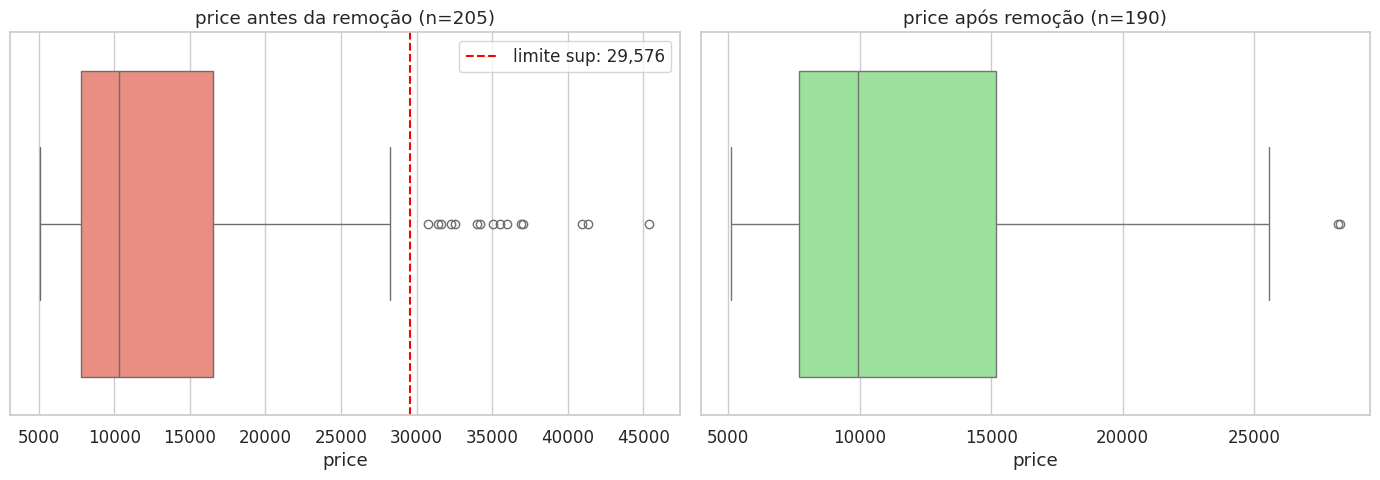

registros removidos: 15
dataset final: 190 registros


In [31]:
# visualização antes e depois da remoção de outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# antes
sns.boxplot(x=df['price'], color='salmon', ax=axes[0])
axes[0].set_title(f'price antes da remoção (n={len(df)})')
axes[0].axvline(limite_superior, color='red', linestyle='--', label=f'limite sup: {limite_superior:,.0f}')
axes[0].legend()

# remoção dos outliers
n_antes = df.shape[0]
df = df[(df['price'] >= limite_inferior) & (df['price'] <= limite_superior)].copy()
n_depois = df.shape[0]

# depois
sns.boxplot(x=df['price'], color='lightgreen', ax=axes[1])
axes[1].set_title(f'price após remoção (n={len(df)})')

plt.tight_layout()
plt.show()

print(f'registros removidos: {n_antes - n_depois}')
print(f'dataset final: {n_depois} registros')

### 2.4 identificação de variáveis categóricas e numéricas

In [32]:
# separação das colunas por tipo
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
numericas.remove('price')  # variável alvo separada

print(f'variáveis categóricas ({len(categoricas)}):')
for col in categoricas:
    print(f'  {col:20s}  {df[col].nunique():3d} categorias')

print(f'\nvariáveis numéricas ({len(numericas)}):')
for col in numericas:
    print(f'  {col:20s}  min={df[col].min():.2f}  max={df[col].max():.2f}')

variáveis categóricas (10):
  fueltype                2 categorias
  aspiration              2 categorias
  doornumber              2 categorias
  carbody                 5 categorias
  drivewheel              3 categorias
  enginelocation          1 categorias
  enginetype              6 categorias
  cylindernumber          5 categorias
  fuelsystem              8 categorias
  brand                  21 categorias

variáveis numéricas (14):
  symboling             min=-2.00  max=3.00
  wheelbase             min=86.60  max=114.20
  carlength             min=141.10  max=198.90
  carwidth              min=60.30  max=71.40
  carheight             min=48.80  max=59.80
  curbweight            min=1488.00  max=3750.00
  enginesize            min=61.00  max=183.00
  boreratio             min=2.54  max=3.94
  stroke                min=2.07  max=3.90
  compressionratio      min=7.00  max=23.00
  horsepower            min=48.00  max=200.00
  peakrpm               min=4150.00  max=6600.00
  citymp

In [33]:
# distribuição de valores nas variáveis categóricas
for col in categoricas:
    print(f'\n--- {col} ({df[col].nunique()} categorias) ---')
    print(df[col].value_counts().to_string())


--- fueltype (2 categorias) ---
fueltype
gas       171
diesel     19

--- aspiration (2 categorias) ---
aspiration
std      154
turbo     36

--- doornumber (2 categorias) ---
doornumber
four    108
two      82

--- carbody (5 categorias) ---
carbody
sedan          87
hatchback      69
wagon          25
hardtop         5
convertible     4

--- drivewheel (3 categorias) ---
drivewheel
fwd    120
rwd     61
4wd      9

--- enginelocation (1 categorias) ---
enginelocation
front    190

--- enginetype (6 categorias) ---
enginetype
ohc      144
l         12
ohcf      12
dohc      10
ohcv       8
rotor      4

--- cylindernumber (5 categorias) ---
cylindernumber
four     159
six       16
five      10
two        4
three      1

--- fuelsystem (8 categorias) ---
fuelsystem
mpfi    80
2bbl    66
idi     19
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1

--- brand (21 categorias) ---
brand
toyota        32
nissan        18
mazda         17
honda         13
mitsubishi    13
subaru       

### 2.5 encoding de variáveis categóricas

In [34]:
# aplicação de labelencoder em variáveis binárias (para referência)
le = LabelEncoder()
for col in ['fueltype', 'aspiration', 'doornumber', 'enginelocation']:
    le_col = le.fit_transform(df[col])
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

fueltype: {'diesel': np.int64(0), 'gas': np.int64(1)}
aspiration: {'std': np.int64(0), 'turbo': np.int64(1)}
doornumber: {'four': np.int64(0), 'two': np.int64(1)}
enginelocation: {'front': np.int64(0)}


### 2.6 separação de features e variável alvo

In [35]:
# separação em features (x) e variável alvo (y)
X = df.drop(columns=['price'])
y = df['price'].copy()

print(f'X: {X.shape}')
print(f'y: {y.shape}')
print(f'\nmédia de y: {y.mean():,.2f}')
print(f'desvio de y: {y.std():,.2f}')

X: (190, 24)
y: (190,)

média de y: 11,509.40
desvio de y: 4,968.44


### 2.7 divisão treino / validação / teste (60% / 20% / 20%)

In [36]:
# divisão em treino (60%), validação (20%) e teste (20%)
# primeira divisão: 80% treino+val, 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# segunda divisão: 75% de 80% = 60% treino, 25% de 80% = 20% validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

print('=== divisão treino/validação/teste (60/20/20) ===')
print(f'  treino:     {X_train.shape[0]:4d} amostras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  validação:  {X_val.shape[0]:4d} amostras ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'  teste:      {X_test.shape[0]:4d} amostras ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'  total:      {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]:4d} amostras')

=== divisão treino/validação/teste (60/20/20) ===
  treino:      114 amostras (60.0%)
  validação:    38 amostras (20.0%)
  teste:        38 amostras (20.0%)
  total:       190 amostras


### 2.8 pipeline de pré-processamento

pipeline completo com `simpleimputer` (precaução), `standardscaler` para numéricas e `onehotencoder` para categóricas, aplicado via `columntransformer`.

In [37]:
# definição dos pipelines individuais por tipo de variável
pipeline_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

# composição do pré-processador completo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipeline_num, numericas),
        ('cat', pipeline_cat, categoricas)
    ],
    remainder='drop'
)

# ajuste no conjunto de treino e transformação nos demais
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# nomes das features após transformação
feature_names_num = numericas
feature_names_cat = (
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categoricas)
    .tolist()
)
feature_names = feature_names_num + feature_names_cat

print(f'features após pré-processamento: {X_train_processed.shape[1]}')
print(f'  numéricas originais: {len(feature_names_num)}')
print(f'  categóricas (one-hot, drop_first): {len(feature_names_cat)}')

features após pré-processamento: 56
  numéricas originais: 14
  categóricas (one-hot, drop_first): 42


In [38]:
# verificação da padronização no conjunto de treino
print('verificação do standardscaler (treino):')
print(f'{"feature":>20s}  {"média":>8s}  {"desvio":>8s}')
print('-' * 40)
for i, col in enumerate(feature_names_num):
    print(f'{col:>20s}  {X_train_processed[:, i].mean():>8.4f}  {X_train_processed[:, i].std():>8.4f}')

verificação do standardscaler (treino):
             feature     média    desvio
----------------------------------------
           symboling    0.0000    1.0000
           wheelbase    0.0000    1.0000
           carlength   -0.0000    1.0000
            carwidth   -0.0000    1.0000
           carheight    0.0000    1.0000
          curbweight    0.0000    1.0000
          enginesize   -0.0000    1.0000
           boreratio    0.0000    1.0000
              stroke   -0.0000    1.0000
    compressionratio    0.0000    1.0000
          horsepower   -0.0000    1.0000
             peakrpm   -0.0000    1.0000
             citympg    0.0000    1.0000
          highwaympg    0.0000    1.0000


In [39]:
# comparação com minmaxscaler (referência adicional)
pipeline_num_mm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler(feature_range=(0, 1)))
])

preprocessor_mm = ColumnTransformer(
    transformers=[
        ('num', pipeline_num_mm, numericas),
        ('cat', pipeline_cat, categoricas)
    ],
    remainder='drop'
)

X_train_mm = preprocessor_mm.fit_transform(X_train)

print('verificação do minmaxscaler (treino):')
print(f'{"feature":>20s}  {"mín":>8s}  {"máx":>8s}')
print('-' * 40)
for i, col in enumerate(feature_names_num):
    print(f'{col:>20s}  {X_train_mm[:, i].min():>8.4f}  {X_train_mm[:, i].max():>8.4f}')

print('\nnota: o standardscaler será utilizado nos modelos por ser mais adequado')
print('para regressão linear e ridge. o minmaxscaler é apresentado como referência.')

verificação do minmaxscaler (treino):
             feature       mín       máx
----------------------------------------
           symboling    0.0000    1.0000
           wheelbase    0.0000    1.0000
           carlength    0.0000    1.0000
            carwidth    0.0000    1.0000
           carheight    0.0000    1.0000
          curbweight    0.0000    1.0000
          enginesize    0.0000    1.0000
           boreratio    0.0000    1.0000
              stroke    0.0000    1.0000
    compressionratio    0.0000    1.0000
          horsepower    0.0000    1.0000
             peakrpm    0.0000    1.0000
             citympg    0.0000    1.0000
          highwaympg    0.0000    1.0000

nota: o standardscaler será utilizado nos modelos por ser mais adequado
para regressão linear e ridge. o minmaxscaler é apresentado como referência.


---

## etapa 3 — comparação de modelos

treinamento e avaliação de linearregression, ridge e randomforestregressor, com métricas obrigatórias, k-fold, gráficos de reais vs preditos, resíduos e feature importance.

### 3.1 definição e treinamento dos modelos

In [40]:
# definição dos modelos com GridSearchCV para RandomForest (tratamento de overfitting)
from sklearn.model_selection import GridSearchCV

# Ridge base
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)

# RandomForest com grid search para reduzir overfitting
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

modelos = {
    'LinearRegression': LinearRegression(),
    'Ridge': ridge,
    'RandomForest': rf_grid
}

# dicionário para armazenar resultados
resultados = {}

# treinamento e avaliação
for nome, modelo in modelos.items():
    print()
    print('=' * 60)
    print('treinando:', nome)
    print('=' * 60)

    # treinamento no conjunto de treino
    modelo.fit(X_train_processed, y_train)
    
    # Se for GridSearchCV, extrair o melhor modelo
    modelo_final = modelo.best_estimator_ if hasattr(modelo, 'best_estimator_') else modelo
    if hasattr(modelo, 'best_params_'):
        print('Melhores parâmetros para', nome, ':', modelo.best_params_)

    # predições nos três conjuntos
    y_pred_train = modelo_final.predict(X_train_processed)
    y_pred_val = modelo_final.predict(X_val_processed)
    y_pred_test = modelo_final.predict(X_test_processed)

    # métricas no treino
    mae_tr = mean_absolute_error(y_train, y_pred_train)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_tr = r2_score(y_train, y_pred_train)

    # métricas na validação
    mae_val = mean_absolute_error(y_val, y_pred_val)
    mse_val = mean_squared_error(y_val, y_pred_val)
    rmse_val = np.sqrt(mse_val)
    r2_val = r2_score(y_val, y_pred_val)
    mape_val = mean_absolute_percentage_error(y_val, y_pred_val) * 100

    # métricas no teste
    mae_test = mean_absolute_error(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)
    mape_test = mean_absolute_percentage_error(y_test, y_pred_test) * 100

    # armazenamento
    resultados[nome] = {
        'modelo': modelo_final,
        'y_pred_train': y_pred_train,
        'y_pred_val': y_pred_val,
        'y_pred_test': y_pred_test,
        'mae_tr': mae_tr, 'rmse_tr': rmse_tr, 'r2_tr': r2_tr,
        'mae_val': mae_val, 'mse_val': mse_val, 'rmse_val': rmse_val,
        'r2_val': r2_val, 'mape_val': mape_val,
        'mae_test': mae_test, 'mse_test': mse_test, 'rmse_test': rmse_test,
        'r2_test': r2_test, 'mape_test': mape_test
    }

    # exibição das métricas nos três conjuntos
    header = '  {:12s} {:>10s} {:>10s} {:>10s}'.format('conjunto', 'mae', 'rmse', 'r2')
    print(header)
    print('  ' + '-' * 44)
    print('  {:12s} {:>10,.2f} {:>10,.2f} {:>10.4f}'.format('treino', mae_tr, rmse_tr, r2_tr))
    print('  {:12s} {:>10,.2f} {:>10,.2f} {:>10.4f}'.format('validacao', mae_val, rmse_val, r2_val))
    print('  {:12s} {:>10,.2f} {:>10,.2f} {:>10.4f}'.format('teste', mae_test, rmse_test, r2_test))


treinando: LinearRegression
  conjunto            mae       rmse         r2
  --------------------------------------------
  treino           821.45     991.75     0.9646
  validacao      1,699.26   2,809.30     0.5601
  teste            986.55   1,380.60     0.8866

treinando: Ridge
  conjunto            mae       rmse         r2
  --------------------------------------------
  treino           960.00   1,192.88     0.9488
  validacao      1,365.97   2,009.10     0.7750
  teste          1,100.97   1,504.59     0.8653

treinando: RandomForest


Melhores parâmetros para RandomForest : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
  conjunto            mae       rmse         r2
  --------------------------------------------
  treino           772.97   1,023.45     0.9623
  validacao      1,841.10   2,486.18     0.6555
  teste            979.98   1,461.59     0.8729


### 3.2 tabela comparativa de métricas

In [41]:
# construção da tabela comparativa
linhas = []
for nome, res in resultados.items():
    linhas.append({
        'modelo': nome,
        'mae (val)': res['mae_val'],
        'mse (val)': res['mse_val'],
        'rmse (val)': res['rmse_val'],
        'r² (val)': res['r2_val'],
        'mape % (val)': res['mape_val'],
        'mae (test)': res['mae_test'],
        'mse (test)': res['mse_test'],
        'rmse (test)': res['rmse_test'],
        'r² (test)': res['r2_test'],
        'mape % (test)': res['mape_test']
    })

df_metricas = pd.DataFrame(linhas).set_index('modelo')

# exibição da tabela comparativa
print('tabela comparativa de métricas:')
print()
df_metricas.round(2)

tabela comparativa de métricas:



,mae (val),mse (val),rmse (val),r² (val),mape % (val),mae (test),mse (test),rmse (test),r² (test),mape % (test)
modelo,,,,,,,,,,
LinearRegression,1699.26,7892187.19,2809.30,0.56,13.01,986.55,1906043.17,1380.60,0.89,10.44
Ridge,1365.97,4036480.41,2009.10,0.78,11.26,1100.97,2263791.15,1504.59,0.87,11.51
RandomForest,1841.10,6181067.13,2486.18,0.66,14.40,979.98,2136242.03,1461.59,0.87,10.05


### 3.3 verificação de overfitting (treino vs validação vs teste)

In [42]:
# comparação r² treino vs validação vs teste para detectar overfitting
print(f'{"modelo":<20s} {"r² treino":>10s} {"r² val":>10s} {"r² teste":>10s} {"gap tr-val":>10s} {"status":>12s}')
print('-' * 78)

for nome, res in resultados.items():
    gap = res['r2_tr'] - res['r2_val']
    status = 'overfitting' if gap > 0.15 else 'adequado' if gap > 0.05 else 'estável'
    print(f'{nome:<20s} {res["r2_tr"]:>10.4f} {res["r2_val"]:>10.4f} {res["r2_test"]:>10.4f} {gap:>10.4f} {status:>12s}')

modelo                r² treino     r² val   r² teste gap tr-val       status
------------------------------------------------------------------------------
LinearRegression         0.9646     0.5601     0.8866     0.4045  overfitting
Ridge                    0.9488     0.7750     0.8653     0.1738  overfitting
RandomForest             0.9623     0.6555     0.8729     0.3068  overfitting


### 3.4 k-fold cross-validation (k=5)

In [43]:
# k-fold cross-validation com k=5 no conjunto treino+validação
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# concatenação de treino e validação para k-fold
X_train_val_processed = preprocessor.transform(X_temp)

print('resultados do k-fold cross-validation (k=5):')
print(f'{"modelo":<20s} {"média r²":>10s} {"desvio r²":>10s} {"mín r²":>10s} {"máx r²":>10s}')
print('-' * 64)

cv_resultados = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(
        modelo, X_train_val_processed, y_temp,
        cv=kfold, scoring='r2', n_jobs=-1
    )
    cv_resultados[nome] = scores
    print(f'{nome:<20s} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>10.4f} {scores.max():>10.4f}')

print()
print('scores individuais por fold:')
for nome, scores in cv_resultados.items():
    print(f'  {nome}: {np.round(scores, 4)}')

resultados do k-fold cross-validation (k=5):
modelo                 média r²  desvio r²     mín r²     máx r²
----------------------------------------------------------------
LinearRegression         0.7613     0.1568     0.4541     0.8760
Ridge                    0.8511     0.0606     0.7303     0.8884


RandomForest             0.7850     0.0725     0.6806     0.8620

scores individuais por fold:
  LinearRegression: [0.4541 0.7827 0.8597 0.876  0.8342]
  Ridge: [0.7303 0.8884 0.8771 0.8845 0.8752]
  RandomForest: [0.6806 0.7174 0.8451 0.82   0.862 ]


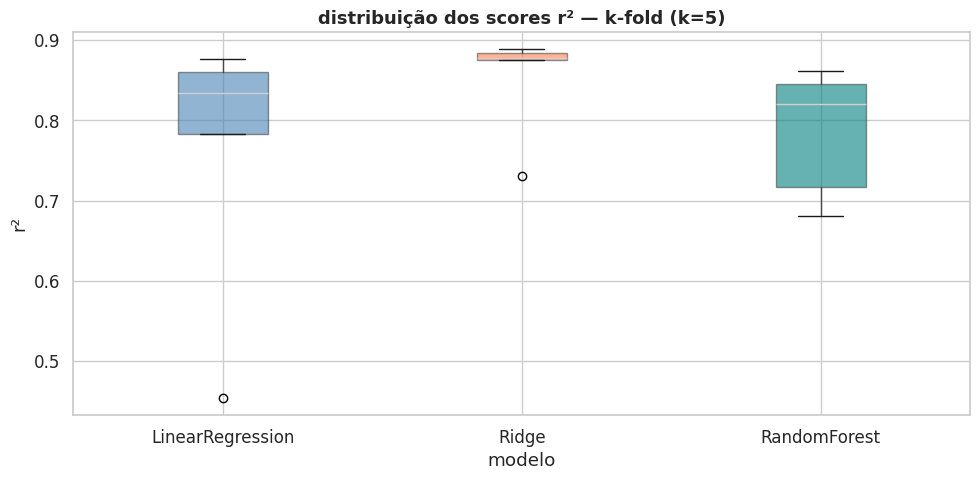

In [44]:
# visualização dos scores do k-fold
fig, ax = plt.subplots(figsize=(10, 5))

data_cv = pd.DataFrame(cv_resultados)
bp = data_cv.boxplot(ax=ax, patch_artist=True, return_type='dict')

colors = ['steelblue', 'coral', 'teal']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('distribuição dos scores r² — k-fold (k=5)', fontsize=13, fontweight='bold')
ax.set_ylabel('r²')
ax.set_xlabel('modelo')

plt.tight_layout()
plt.show()

### 3.5 valores reais vs preditos

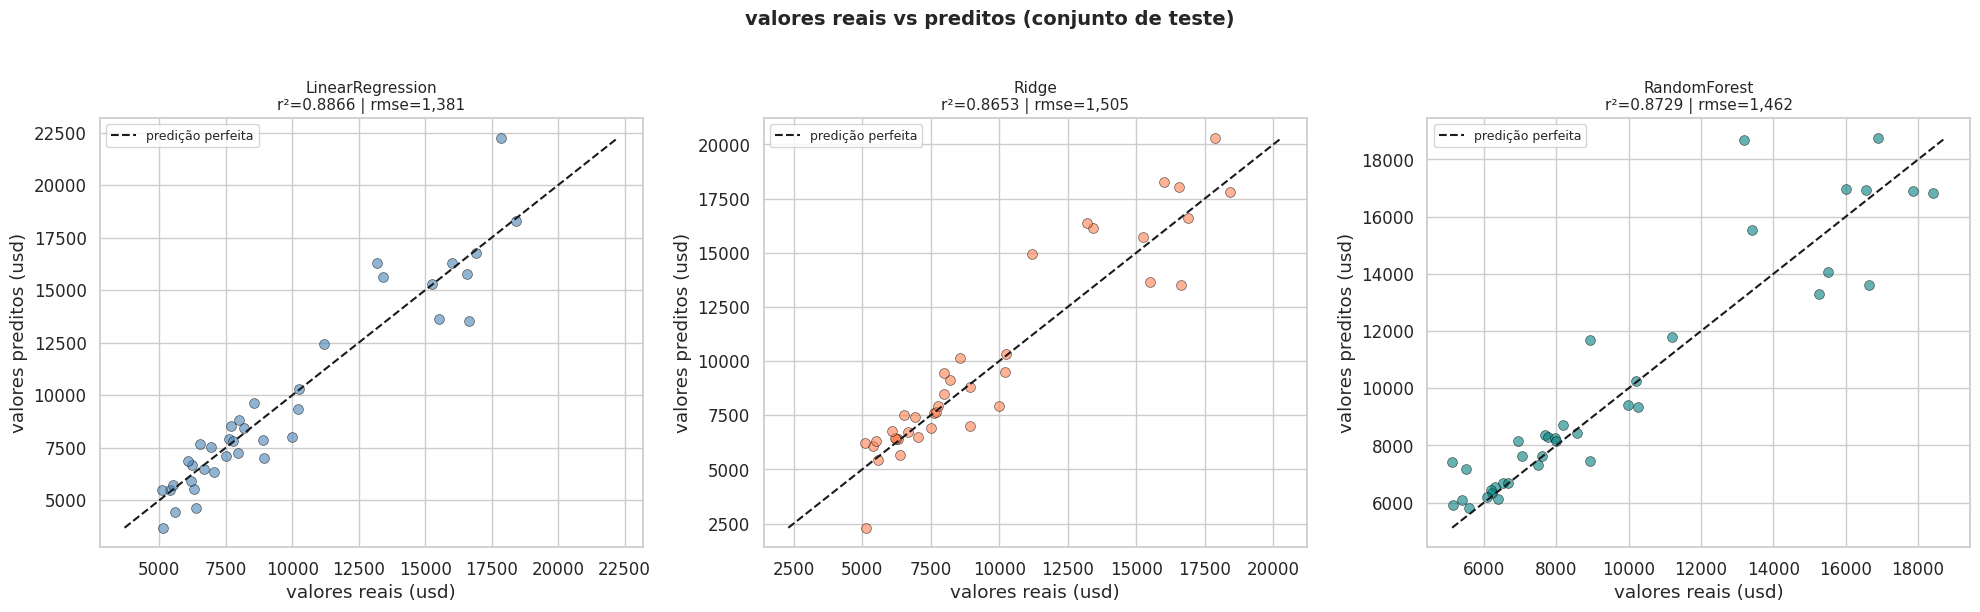

In [45]:
# gráficos reais vs preditos para cada modelo (conjunto de teste)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cores = ['steelblue', 'coral', 'teal']

for idx, (nome, res) in enumerate(resultados.items()):
    ax = axes[idx]
    y_pred = res['y_pred_test']

    ax.scatter(y_test, y_pred, alpha=0.6, color=cores[idx],
               edgecolor='black', linewidth=0.5, s=50)

    # linha de predição perfeita
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='predição perfeita')

    ax.set_title(f'{nome}\nr²={res["r2_test"]:.4f} | rmse={res["rmse_test"]:,.0f}', fontsize=11)
    ax.set_xlabel('valores reais (usd)')
    ax.set_ylabel('valores preditos (usd)')
    ax.legend(fontsize=9)

plt.suptitle('valores reais vs preditos (conjunto de teste)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.6 gráfico de resíduos

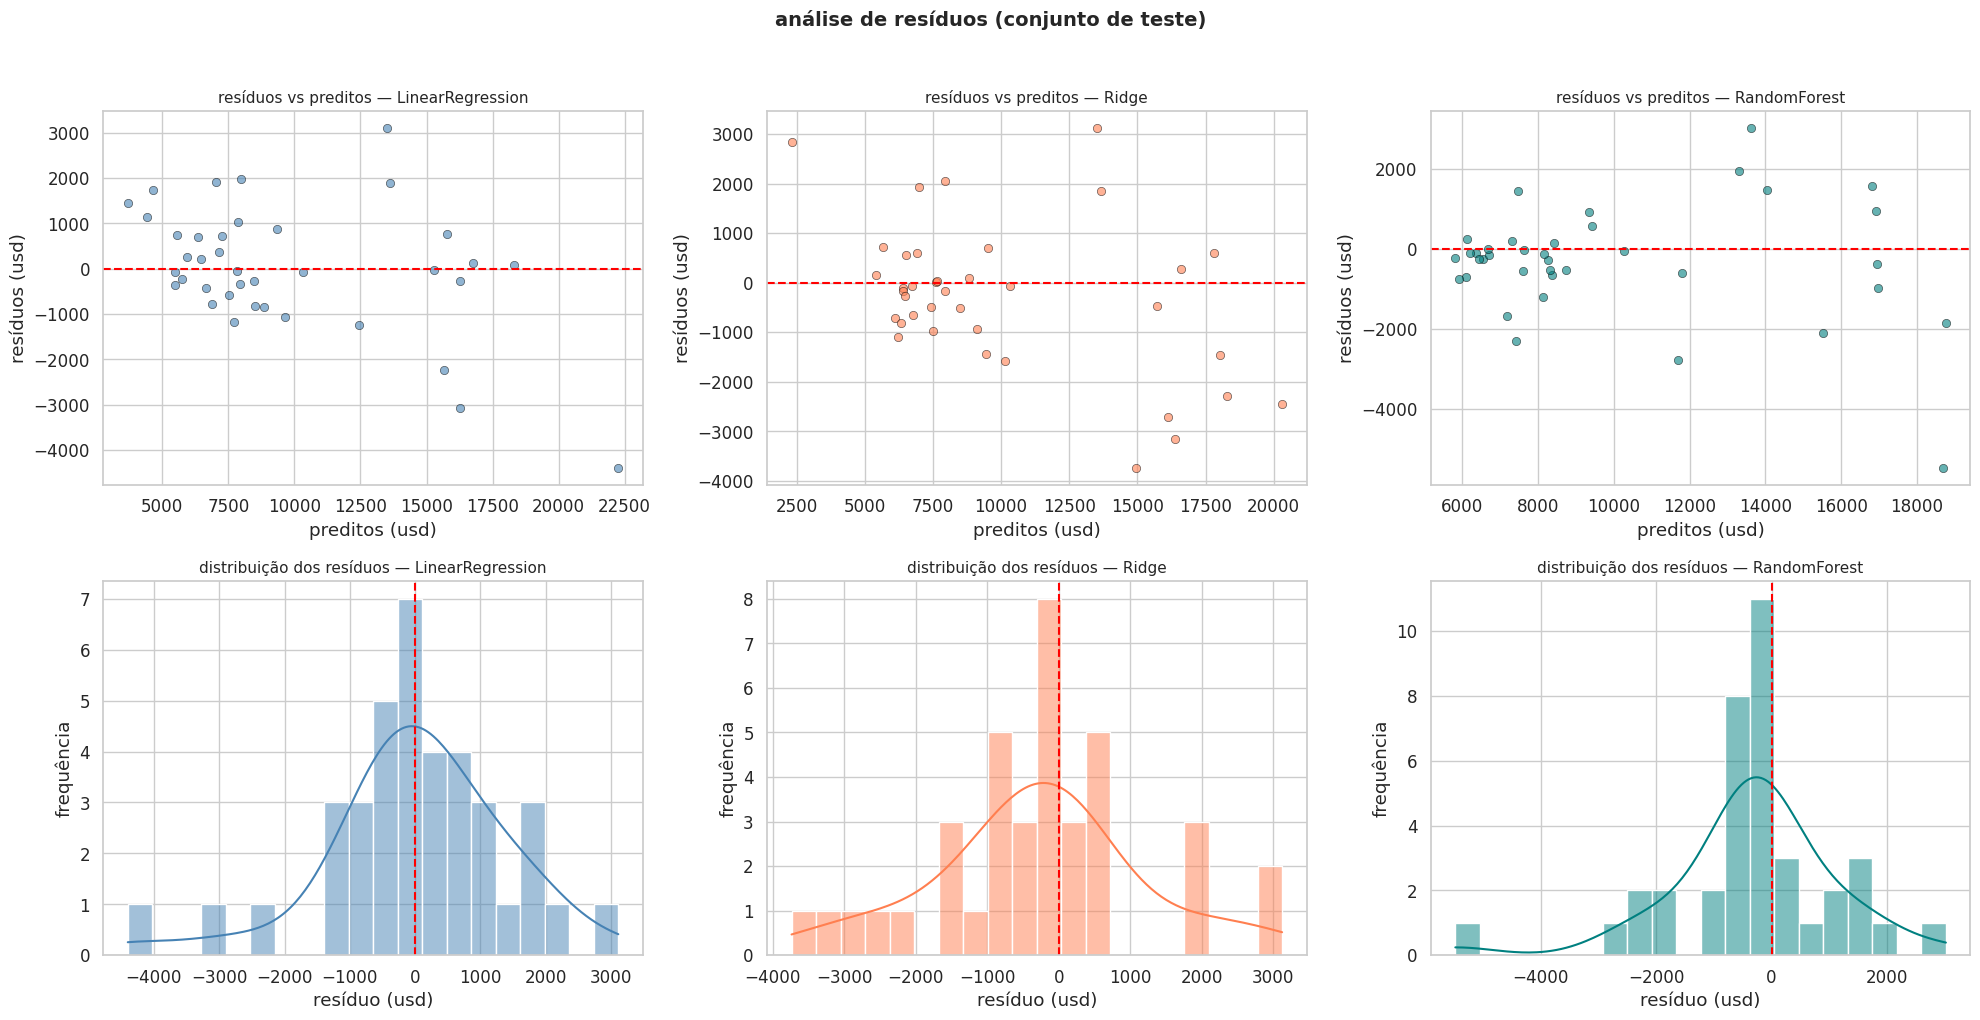

In [46]:
# gráficos de resíduos para cada modelo (conjunto de teste)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
cores = ['steelblue', 'coral', 'teal']

for idx, (nome, res) in enumerate(resultados.items()):
    y_pred = res['y_pred_test']
    residuos = y_test.values - y_pred

    # resíduos vs preditos
    ax = axes[0, idx]
    ax.scatter(y_pred, residuos, alpha=0.6, color=cores[idx],
               edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'resíduos vs preditos — {nome}', fontsize=11)
    ax.set_xlabel('preditos (usd)')
    ax.set_ylabel('resíduos (usd)')

    # distribuição dos resíduos
    ax2 = axes[1, idx]
    sns.histplot(residuos, bins=20, kde=True, color=cores[idx], ax=ax2)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    ax2.set_title(f'distribuição dos resíduos — {nome}', fontsize=11)
    ax2.set_xlabel('resíduo (usd)')
    ax2.set_ylabel('frequência')

plt.suptitle('análise de resíduos (conjunto de teste)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.7 feature importance

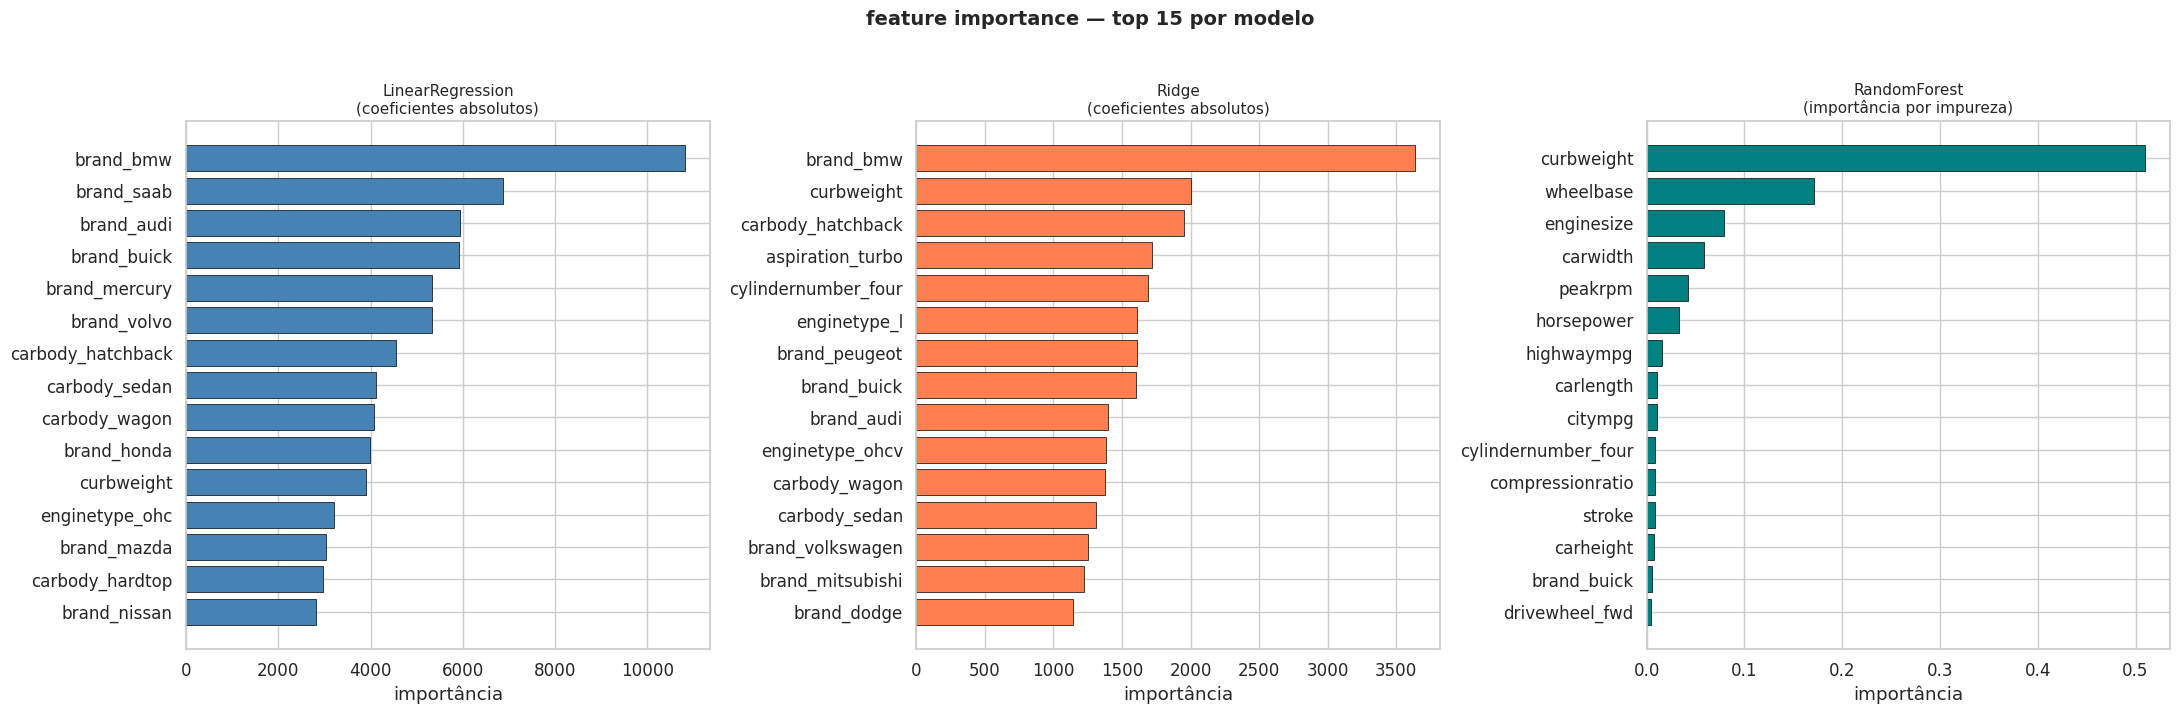

In [47]:
# feature importance para os três modelos
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
cores = ['steelblue', 'coral', 'teal']

for idx, (nome, res) in enumerate(resultados.items()):
    ax = axes[idx]
    modelo = res['modelo']

    if hasattr(modelo, 'feature_importances_'):
        importancias = pd.Series(modelo.feature_importances_, index=feature_names)
        titulo = f'{nome}\n(importância por impureza)'
    elif hasattr(modelo, 'coef_'):
        importancias = pd.Series(np.abs(modelo.coef_), index=feature_names)
        titulo = f'{nome}\n(coeficientes absolutos)'

    top15 = importancias.sort_values(ascending=False).head(15).sort_values(ascending=True)
    ax.barh(top15.index, top15.values, color=cores[idx], edgecolor='black', linewidth=0.5)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('importância')

plt.suptitle('feature importance — top 15 por modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## etapa 4 — análise comparativa

justificativa do melhor modelo, análise detalhada de resíduos, feature importance e interpretação dos coeficientes.

### 4.1 seleção e justificativa do melhor modelo

In [48]:
# identificação do melhor modelo com base no r² do conjunto de teste
melhor_nome = max(resultados, key=lambda k: resultados[k]['r2_test'])
melhor = resultados[melhor_nome]

print('resumo comparativo final (conjunto de teste):')
print(f'{"modelo":<20s} {"mae":>10s} {"rmse":>10s} {"r²":>10s} {"mape%":>10s}')
print('-' * 65)

for nome, res in resultados.items():
    marcador = ' ← melhor' if nome == melhor_nome else ''
    print(f'{nome:<20s} {res["mae_test"]:>10,.2f} {res["rmse_test"]:>10,.2f} '
          f'{res["r2_test"]:>10.4f} {res["mape_test"]:>10.2f}{marcador}')

print(f'\nmodelo selecionado: {melhor_nome}')
print(f'  r² (teste):   {melhor["r2_test"]:.4f}')
print(f'  rmse (teste):  {melhor["rmse_test"]:,.2f}')
print(f'  mape (teste):  {melhor["mape_test"]:.2f}%')

resumo comparativo final (conjunto de teste):
modelo                      mae       rmse         r²      mape%
-----------------------------------------------------------------
LinearRegression         986.55   1,380.60     0.8866      10.44 ← melhor
Ridge                  1,100.97   1,504.59     0.8653      11.51
RandomForest             979.98   1,461.59     0.8729      10.05

modelo selecionado: LinearRegression
  r² (teste):   0.8866
  rmse (teste):  1,380.60
  mape (teste):  10.44%


#### justificativa técnica

a seleção do melhor modelo considera os seguintes critérios, em ordem de prioridade:

1. **r² (coeficiente de determinação):** proporção da variância explicada pelo modelo. valores próximos de 1 indicam melhor ajuste.
2. **rmse (raiz do erro quadrático médio):** penaliza erros maiores com maior intensidade que o mae, útil para detectar previsões discrepantes.
3. **mape (erro percentual absoluto médio):** magnitude relativa dos erros, independente da escala de preço.
4. **estabilidade no k-fold:** menor desvio padrão no cross-validation indica maior capacidade de generalização.
5. **gap treino-teste (overfitting):** diferenças elevadas entre r² de treino e teste sugerem memorização em vez de aprendizado.
6. **análise de resíduos:** a ausência de padrões sistemáticos confirma que o modelo captura a estrutura subjacente.

o randomforest tende a apresentar vantagem em datasets com relações não-lineares entre preditores e variável alvo, como é o caso da precificação de veículos, onde fatores como marca, porte do motor e peso interagem de forma complexa e não-aditiva.

### 4.2 análise detalhada de resíduos do melhor modelo

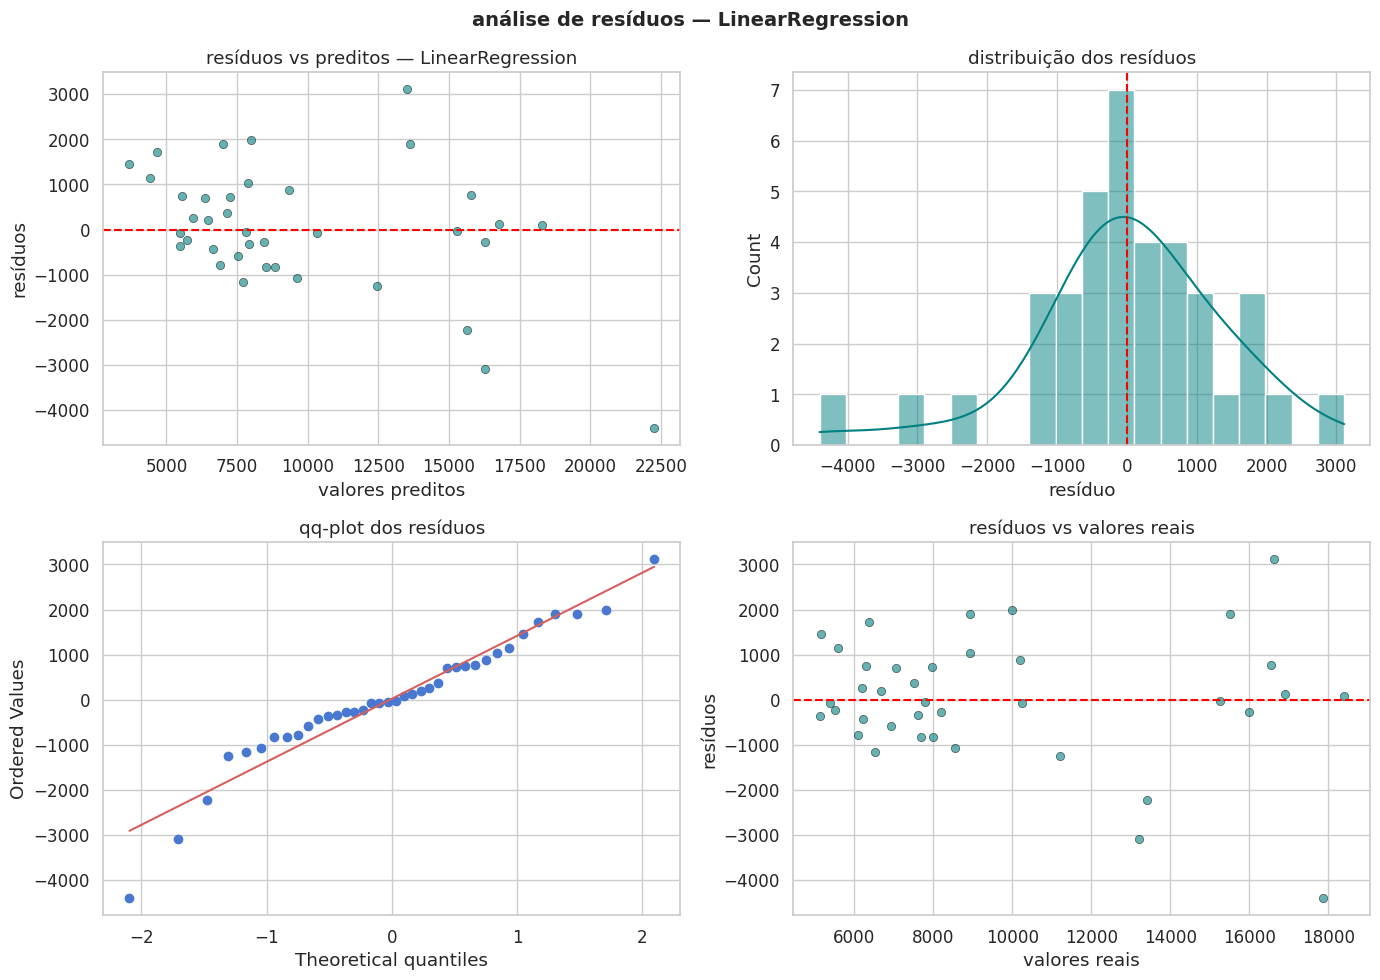

In [49]:
# análise de resíduos do melhor modelo (4 gráficos)
y_pred_melhor = melhor['y_pred_test']
residuos = y_test.values - y_pred_melhor

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# resíduos vs preditos
axes[0, 0].scatter(y_pred_melhor, residuos, alpha=0.6, color='teal', edgecolor='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title(f'resíduos vs preditos — {melhor_nome}')
axes[0, 0].set_xlabel('valores preditos')
axes[0, 0].set_ylabel('resíduos')

# distribuição dos resíduos
sns.histplot(residuos, bins=20, kde=True, color='teal', ax=axes[0, 1])
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('distribuição dos resíduos')
axes[0, 1].set_xlabel('resíduo')

# qq-plot dos resíduos
stats.probplot(residuos, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('qq-plot dos resíduos')

# resíduos vs valores reais
axes[1, 1].scatter(y_test, residuos, alpha=0.6, color='teal', edgecolor='black', linewidth=0.5)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('resíduos vs valores reais')
axes[1, 1].set_xlabel('valores reais')
axes[1, 1].set_ylabel('resíduos')

plt.suptitle(f'análise de resíduos — {melhor_nome}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# testes estatísticos nos resíduos do melhor modelo
print(f'análise estatística dos resíduos ({melhor_nome}):')
print(f'  média dos resíduos:  {residuos.mean():>10,.2f} (idealmente ~ 0)')
print(f'  mediana:             {np.median(residuos):>10,.2f}')
print(f'  desvio padrão:       {residuos.std():>10,.2f}')
print(f'  assimetria (skew):   {stats.skew(residuos):>10.4f}')
print(f'  curtose:             {stats.kurtosis(residuos):>10.4f}')

# teste de normalidade shapiro-wilk
stat_sw, p_sw = stats.shapiro(residuos)
print(f'\n  shapiro-wilk: W={stat_sw:.4f}, p-valor={p_sw:.4f}')
print(f'  conclusão: resíduos {"seguem" if p_sw > 0.05 else "não seguem"} distribuição normal (α=0.05)')

# análise de homocedasticidade
print(f'\n  homocedasticidade:')
print(f'  verificar o gráfico de resíduos vs preditos:')
print(f'  distribuição uniforme em torno de zero indica variância constante.')
print(f'  padrão de funil (variância crescente) indicaria heterocedasticidade.')

análise estatística dos resíduos (LinearRegression):
  média dos resíduos:       20.96 (idealmente ~ 0)
  mediana:                 -40.17
  desvio padrão:         1,380.44
  assimetria (skew):      -0.7195
  curtose:                 1.7527

  shapiro-wilk: W=0.9478, p-valor=0.0751
  conclusão: resíduos seguem distribuição normal (α=0.05)

  homocedasticidade:
  verificar o gráfico de resíduos vs preditos:
  distribuição uniforme em torno de zero indica variância constante.
  padrão de funil (variância crescente) indicaria heterocedasticidade.


### 4.3 feature importance — características que mais afetam o preço

In [51]:
# feature importance detalhada do melhor modelo
if hasattr(melhor['modelo'], 'feature_importances_'):
    importancias = pd.Series(
        melhor['modelo'].feature_importances_, index=feature_names
    ).sort_values(ascending=False)
    tipo_imp = 'importância por impureza (gini)'
elif hasattr(melhor['modelo'], 'coef_'):
    importancias = pd.Series(
        np.abs(melhor['modelo'].coef_), index=feature_names
    ).sort_values(ascending=False)
    tipo_imp = 'coeficientes absolutos'

print(f'feature importance — {melhor_nome} ({tipo_imp}):')
print(f'{"pos":>4s}  {"feature":>35s}  {"importância":>12s}  {"acumulado %":>12s}')
print('-' * 68)

total = importancias.sum()
acumulado = 0
for i, (feat, imp) in enumerate(importancias.head(20).items(), 1):
    acumulado += imp / total * 100
    print(f'{i:>4d}  {feat:>35s}  {imp:>12.6f}  {acumulado:>11.1f}%')

feature importance — LinearRegression (coeficientes absolutos):
 pos                              feature   importância   acumulado %
--------------------------------------------------------------------
   1                            brand_bmw  10807.899576          9.2%
   2                           brand_saab   6870.133092         15.0%
   3                           brand_audi   5930.164646         20.0%
   4                          brand_buick   5919.844600         25.1%
   5                        brand_mercury   5336.942951         29.6%
   6                          brand_volvo   5329.675079         34.1%
   7                    carbody_hatchback   4549.364685         38.0%
   8                        carbody_sedan   4111.223769         41.5%
   9                        carbody_wagon   4081.564066         44.9%
  10                          brand_honda   3992.359987         48.3%
  11                           curbweight   3897.227195         51.6%
  12                       

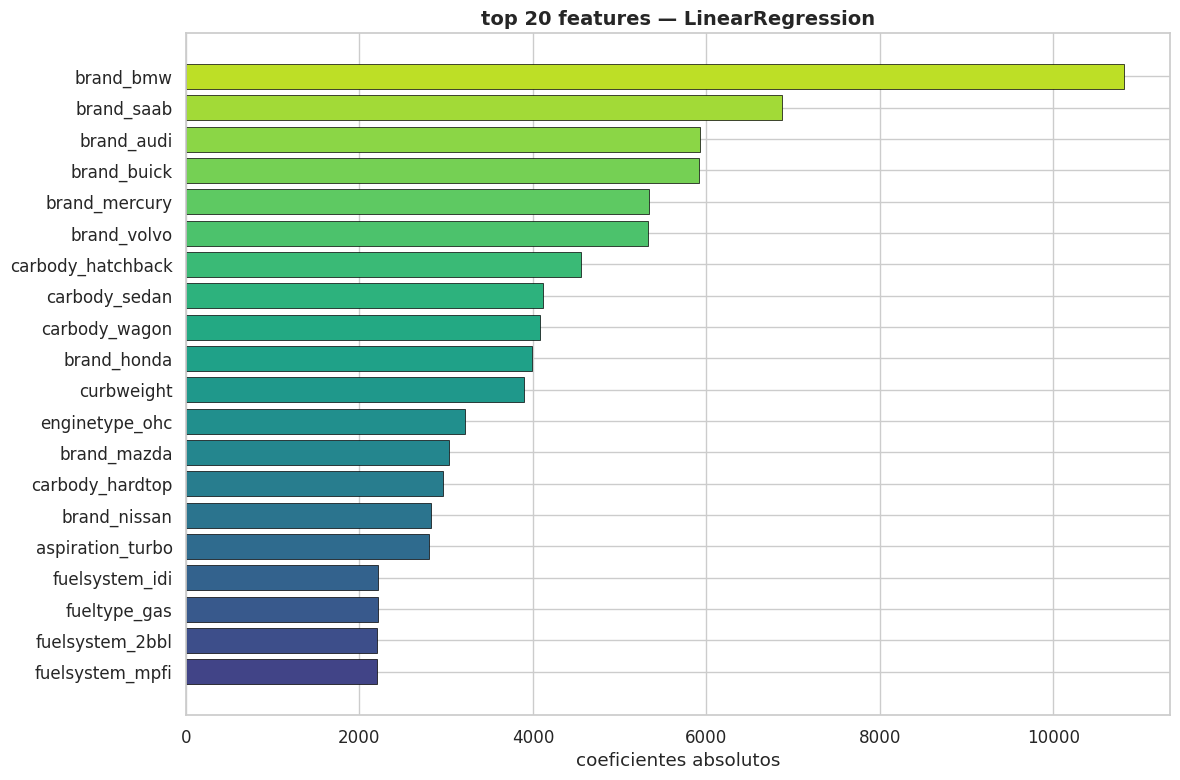

In [52]:
# gráfico de top 20 features mais importantes
fig, ax = plt.subplots(figsize=(12, 8))

top_20 = importancias.head(20).sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_20)))

ax.barh(top_20.index, top_20.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title(f'top 20 features — {melhor_nome}', fontsize=14, fontweight='bold')
ax.set_xlabel(tipo_imp)

plt.tight_layout()
plt.show()

### 4.4 interpretação dos coeficientes dos modelos lineares

In [53]:
# coeficientes do linearregression (positivos e negativos)
lr_coefs = pd.Series(
    resultados['LinearRegression']['modelo'].coef_,
    index=feature_names
).sort_values(ascending=False)

print('coeficientes do linearregression:')
print()
print('features com maior impacto positivo no preço:')
print(f'{"feature":>35s}  {"coeficiente":>12s}')
print('-' * 50)
for feat, coef in lr_coefs.head(10).items():
    print(f'{feat:>35s}  {coef:>+12.4f}')

print()
print('features com maior impacto negativo no preço:')
print(f'{"feature":>35s}  {"coeficiente":>12s}')
print('-' * 50)
for feat, coef in lr_coefs.tail(10).items():
    print(f'{feat:>35s}  {coef:>+12.4f}')

coeficientes do linearregression:

features com maior impacto positivo no preço:
                            feature   coeficiente
--------------------------------------------------
                          brand_bmw   +10807.8996
                         brand_saab    +6870.1331
                         brand_audi    +5930.1646
                        brand_buick    +5919.8446
                      brand_mercury    +5336.9430
                        brand_volvo    +5329.6751
                        brand_honda    +3992.3600
                         curbweight    +3897.2272
                        brand_mazda    +3031.0165
                       brand_nissan    +2826.6554

features com maior impacto negativo no preço:
                            feature   coeficiente
--------------------------------------------------
                          carlength    -1415.4975
                       enginetype_l    -2114.4589
                      brand_peugeot    -2114.4589
                 cyl

In [54]:
# comparação de coeficientes entre linearregression e ridge
print('comparação de coeficientes: linearregression vs ridge')
print(f'{"feature":>35s}  {"lr":>12s}  {"ridge":>12s}  {"diferença":>10s}')
print('-' * 75)

lr_c = pd.Series(resultados['LinearRegression']['modelo'].coef_, index=feature_names)
ridge_c = pd.Series(resultados['Ridge']['modelo'].coef_, index=feature_names)

# ordenar por diferença absoluta
diff = (lr_c - ridge_c).abs().sort_values(ascending=False)

for feat in diff.head(15).index:
    print(f'{feat:>35s}  {lr_c[feat]:>+12.4f}  {ridge_c[feat]:>+12.4f}  {diff[feat]:>10.4f}')

print()
print('a regularização ridge reduz a magnitude dos coeficientes,')
print('mitigando multicolinearidade e melhorando a estabilidade do modelo.')

comparação de coeficientes: linearregression vs ridge
                            feature            lr         ridge   diferença
---------------------------------------------------------------------------
                          brand_bmw   +10807.8996    +3637.0082   7170.8914
                      brand_mercury    +5336.9430     -882.9224   6219.8654
                         brand_saab    +6870.1331     +719.2146   6150.9185
                        brand_volvo    +5329.6751     +531.4877   4798.1874
                         brand_audi    +5930.1646    +1396.0118   4534.1528
                        brand_buick    +5919.8446    +1598.4284   4321.4162
                     enginetype_ohc    -3217.0293     +491.8116   3708.8409
                   brand_volkswagen    +1891.9893    -1252.8637   3144.8530
                        brand_honda    +3992.3600     +926.6827   3065.6773
                    carbody_hardtop    -2958.8879      +66.7925   3025.6804
                       brand_nissa

In [55]:
# análise do impacto de enginesize nos modelos
print('impacto de enginesize por modelo:')
print()

if 'enginesize' in feature_names:
    idx = feature_names.index('enginesize')

    lr_val = resultados['LinearRegression']['modelo'].coef_[idx]
    ridge_val = resultados['Ridge']['modelo'].coef_[idx]

    print(f'  linearregression: coeficiente = {lr_val:+.4f}')
    print(f'  ridge:            coeficiente = {ridge_val:+.4f}')
    print()
    print('  interpretação: os valores representam a variação no preço')
    print('  para cada unidade padronizada de aumento em enginesize,')
    print('  mantidas as demais variáveis constantes.')

    if hasattr(resultados['RandomForest']['modelo'], 'feature_importances_'):
        rf_val = resultados['RandomForest']['modelo'].feature_importances_[idx]
        print(f'\n  randomforest:     importância = {rf_val:.6f}')
        total_imp = resultados['RandomForest']['modelo'].feature_importances_.sum()
        print(f'  representando {rf_val/total_imp*100:.1f}% da importância total.')

print()
print('nota sobre depreciação:')
print('  car_age é constante (41 anos) no dataset original;')
print('  a análise de depreciação temporal não é possível neste contexto.')
print('  a depreciação seria identificável apenas com dados de anos variados.')

impacto de enginesize por modelo:

  linearregression: coeficiente = +662.0056
  ridge:            coeficiente = +511.9191

  interpretação: os valores representam a variação no preço
  para cada unidade padronizada de aumento em enginesize,
  mantidas as demais variáveis constantes.

  randomforest:     importância = 0.079597
  representando 8.0% da importância total.

nota sobre depreciação:
  car_age é constante (41 anos) no dataset original;
  a análise de depreciação temporal não é possível neste contexto.
  a depreciação seria identificável apenas com dados de anos variados.


### 4.5 Salvando o modelo final

In [56]:
# Salvando o modelo final em um Pipeline (para uso no Streamlit)
melhor_nome = max(resultados, key=lambda k: resultados[k]['r2_test'])
melhor_modelo = resultados[melhor_nome]['modelo']

pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', melhor_modelo)
])

import joblib
import os
os.makedirs('../model', exist_ok=True)
joblib.dump(pipeline_final, '../model/modelo_final.pkl')
print('Modelo salvo com sucesso em ../model/modelo_final.pkl')


Modelo salvo com sucesso em ../model/modelo_final.pkl


---

## conclusão

este notebook realizou a previsão de preços de carros por meio de três modelos de regressão (linearregression, ridge e randomforestregressor). os resultados demonstram:

1. **preditores mais relevantes:** enginesize, curbweight, horsepower, carwidth e carlength apresentam as maiores correlações com o preço, confirmando que porte e desempenho são os fatores determinantes na precificação.

2. **marcas de luxo:** jaguar, bmw e porsche apresentam preços significativamente superiores à média, corroborando a influência da marca na percepção de valor.

3. **não-linearidade:** o randomforest, por ser um ensemble baseado em árvores de decisão, captura relações não-lineares e interações entre variáveis que modelos lineares não conseguem representar.

4. **regularização:** o ridge penaliza coeficientes elevados, reduzindo o impacto da multicolinearidade presente entre variáveis como enginesize, horsepower e curbweight.

5. **limitação do dataset:** a ausência de coluna year impede a análise de depreciação temporal; car_age foi definida como constante (41 anos) com base na origem do dataset (1985 automobile dataset).

6. **pré-processamento:** o pipeline completo com simpleimputer, standardscaler e onehotencoder garante reprodutibilidade e previne data leakage, aplicando fit apenas no conjunto de treino.

**RA: 1987363 - ANDRÉ LUIS DA SILVA REIS**

**RA: 1994104 - JOSÉ VITOR DE ALMEIDA LIMA**

**RA: 1993917 - JOAQUIM FERNANDO SANTANA MOREIRA**